<a href="https://colab.research.google.com/github/michamettler/zhaw-xai/blob/main/01_LIME_SHAP_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%%capture
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
!pip install lime
from lime.lime_tabular import LimeTabularExplainer
from lime import submodular_pick
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from collections import defaultdict
from sklearn.metrics import accuracy_score
import shap
import warnings
warnings.filterwarnings('ignore')

# XAI Lab: LIME and SHAP

In [2]:
# Load data
data = load_breast_cancer(as_frame=True)
X = data.data
y = data.target

display(X.head())

# Create training and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the data
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)

# Create DataFrame version with feature names for SHAP
X_test_df = pd.DataFrame(X_test_s, columns=X.columns.tolist())
feature_names = X.columns.tolist()

print(f"Training set: {X_train_s.shape}, Test set: {X_test_s.shape}")
print(f"Classes: {dict(zip(data.target_names, [sum(y_test==0), sum(y_test==1)]))}")

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


Training set: (455, 30), Test set: (114, 30)
Classes: {np.str_('malignant'): 43, np.str_('benign'): 71}


Complete the coding exercises below.

## LIME

- **Task (0.5 points):** Select a model (e.g. random forest, gradient boosting, neural network) to address the given task and fit it on the dataset.
- **Task (0.5 points):** Run LIME explainer for the trained model.
- **Task (1 point):** Run local explanations for 4 test samples of your choice from different classes.
- **Task (1 point):** Barplot of the top 5 most influential and top 5 least influential global features created by averaging the feature importances from 100 randomly chosen test samples. Looking at the bar plot of the least influential global features, do you think these features are genuinely uninformative for cancer diagnosis, or could the model be underutilising potentially relevant signals?
- **Task (1 point):** Plot a global overview of the most important features for the model's predictions for the same 100 randomly chosen test samples in the previous task using SP-LIME.
- **Task (1 point):** Create a heatmap where each row is one of the 100 samples and each column is a feature, with cell colour showing the LIME importance weight. This lets you see at a glance which features drive predictions consistently across samples and which vary. Does the heatmap reveal consistent or varying importance of features across samples?

### Coding Tasks

**Task (0.5 points):** Select a model (e.g. random forest, gradient boosting, neural network) to address the given task and fit it on the dataset.

In [35]:
# Your solution here...

from sklearn.metrics import classification_report

# Fit a random forest classifier with 100 trees
rf_clf = RandomForestClassifier(
    max_features=2,
    n_estimators=100,
    bootstrap=True,
    random_state=42,
)
rf_clf.fit(X_train_s, y_train)

y_pred = rf_clf.predict(X_test_s)

# Model performance on the test set
print("\nModel Performance:")
print(classification_report(y_test, y_pred, target_names=data.target_names))



Model Performance:
              precision    recall  f1-score   support

   malignant       0.98      0.93      0.95        43
      benign       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



**Task (0.5 points):** Run LIME explainer for the trained model.

In [36]:
# Your solution here...

class_names = data.target_names.tolist()  # ['malignant', 'benign']
feature_names = list(X_train.columns)

lime_tabular = LimeTabularExplainer(
    X_train_s,
    feature_names=feature_names,
    class_names=class_names,
    mode="classification"
)

**Task (1 point):** Run local explanations for 4 test samples of your choice from different classes.

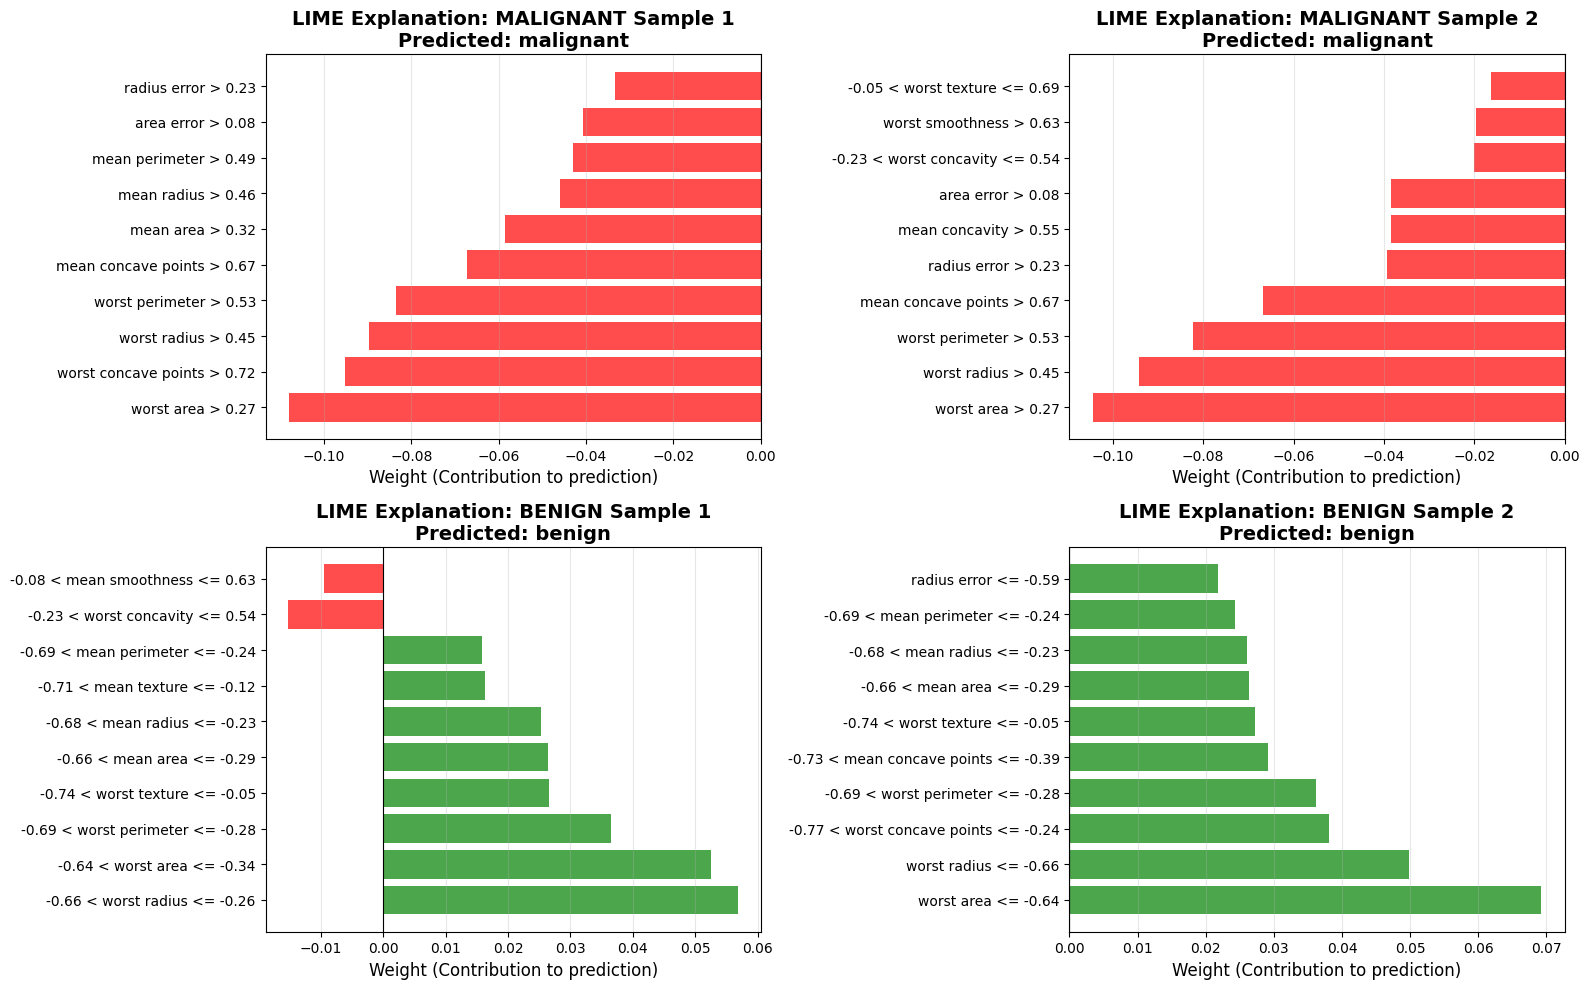

In [50]:
# Your solution here...

# Select 4 samples: 2 malignant, 2 benign
malignant_idx = np.where(y_test.values == 0)[0][:2]
benign_idx = np.where(y_test.values == 1)[0][:2]

# Plot feature importances for the malignant & benign samples
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for idx, (example_idx, label) in enumerate([(malignant_idx[0], 'MALIGNANT Sample 1'),
                                             (malignant_idx[1], 'MALIGNANT Sample 2'),
                                             (benign_idx[0], 'BENIGN Sample 1'),
                                             (benign_idx[1], 'BENIGN Sample 2')]):
    sample = X_test_s[example_idx]
    exp = lime_tabular.explain_instance(sample, rf_clf.predict_proba, num_features=10)
    feat_imp = exp.as_list()

    words = [f[0] for f in feat_imp]
    weights = [f[1] for f in feat_imp]

    colors = ['green' if w > 0 else 'red' for w in weights]
    axes[idx].barh(words, weights, color=colors, alpha=0.7)

    pred_class = np.argmax(exp.predict_proba)
    axes[idx].set_xlabel('Weight (Contribution to prediction)', fontsize=12)
    axes[idx].set_title(f'LIME Explanation: {label}\nPredicted: {class_names[pred_class]}',
                        fontsize=14, fontweight='bold')
    axes[idx].axvline(x=0, color='black', linestyle='-', linewidth=0.8)
    axes[idx].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

**Task (1 point):** Barplot of the top 5 most influential and top 5 least influential global features created by averaging the feature importances from 100 randomly chosen test samples. Looking at the bar plot of the least influential global features, do you think these features are genuinely uninformative for cancer diagnosis, or could the model be underutilising potentially relevant signals?

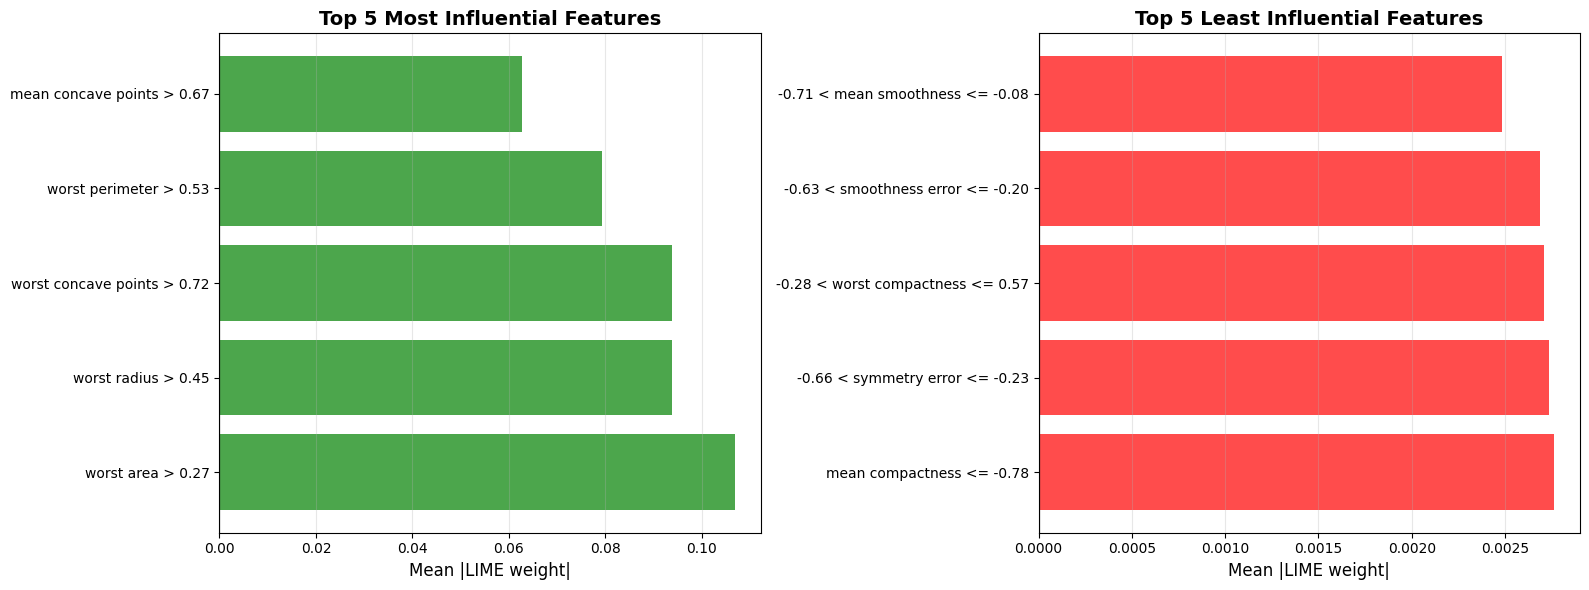

In [38]:
# Your solution here...

np.random.seed(42)
sample_indices = np.random.choice(len(X_test_s), size=100, replace=False)

# Compute feature importance for 100 random test samples using LIME
feature_importance = {}
for idx in range(len(sample_indices)):
    sample = X_test_s[sample_indices[idx]]
    exp = lime_tabular.explain_instance(
        sample,
        rf_clf.predict_proba,
        num_features=len(feature_names)
    )
    for feat, weight in exp.as_list():
        if feat not in feature_importance:
            feature_importance[feat] = []
        feature_importance[feat].append(abs(weight))

# Calculate statistics over the computed importances
feature_stats = {
    feat: {
        'mean': np.mean(weights),
        'std': np.std(weights),
        'count': len(weights)
    }
    for feat, weights in feature_importance.items()
}

# Sort by absolute mean importance
sorted_feats = sorted(feature_stats.items(), key=lambda x: x[1]['mean'], reverse=True)
top5 = sorted_feats[:5]
bottom5 = sorted_feats[-5:]

# Plot top 5 most and least influential
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

feats_top = [f[0] for f in top5]
means_top = [f[1]['mean'] for f in top5]
ax1.barh(feats_top, means_top, color='green', alpha=0.7)
ax1.set_xlabel('Mean |LIME weight|', fontsize=12)
ax1.set_title('Top 5 Most Influential Features',
              fontsize=14, fontweight='bold')
ax1.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax1.grid(axis='x', alpha=0.3)

feats_bottom = [f[0] for f in bottom5]
means_bottom = [f[1]['mean'] for f in bottom5]
ax2.barh(feats_bottom, means_bottom, color='red', alpha=0.7)
ax2.set_xlabel('Mean |LIME weight|', fontsize=12)
ax2.set_title('Top 5 Least Influential Features',
              fontsize=14, fontweight='bold')
ax2.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

**Answer**: I don't think so, features like smoothness, compactness and symmetry definitely could be informative for cancer diagnosis. This could indeed be a sign that the model underutilizes potenial signals.

**Task (1 point):** Plot a global overview of the most important features for the model's predictions for the same 100 randomly chosen test samples in the previous task using SP-LIME.

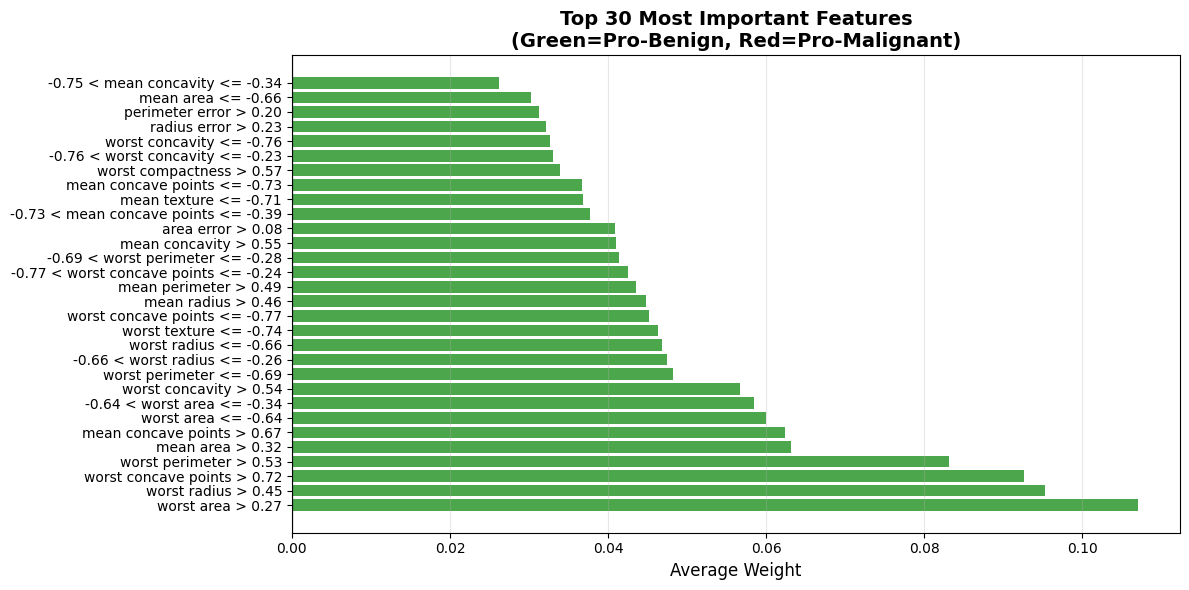

In [39]:
# Your solution here...

n_pool = 100    # Pool of candidates for SP-LIME to evaluate
n_selected = 20  # Number of diverse instances SP-LIME will select

# Use the same 100 random samples from Task 4
# SP-LIME selects a diverse, non-redundant subset that maximises feature coverage
sp_multi = submodular_pick.SubmodularPick(
    lime_tabular, X_test_s[sample_indices], rf_clf.predict_proba,
    num_features=15, num_exps_desired=n_selected, top_labels=1
)

# Compute feature importance from SP-LIME selected explanations
feature_importance_sp = {}

for exp in sp_multi.sp_explanations:
    pred_label = exp.available_labels()[0]
    for feat, weight in exp.as_list(label=pred_label):
        if feat not in feature_importance_sp:
            feature_importance_sp[feat] = []
        feature_importance_sp[feat].append(weight)

feature_stats_sp = {
    feat: {
        'mean': np.mean(weights),
        'std': np.std(weights),
        'count': len(weights)
    }
    for feat, weights in feature_importance_sp.items()
}

# Sort by absolute mean importance
sorted_feats = sorted(feature_stats_sp.items(), key=lambda x: abs(x[1]['mean']), reverse=True)[:30]

# Plot: Average importance
plt.figure(figsize=(12, 6))
feats = [f[0] for f in sorted_feats]
means = [f[1]['mean'] for f in sorted_feats]
colors = ['green' if m > 0 else 'red' for m in means]

plt.barh(feats, means, color=colors, alpha=0.7)
plt.xlabel('Average Weight', fontsize=12)
plt.title('Top 30 Most Important Features\n(Green=Pro-Benign, Red=Pro-Malignant)',
          fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

**Task (1 point):** Create a heatmap where each row is one of the 100 samples and each column is a feature, with cell colour showing the LIME importance weight. This lets you see at a glance which features drive predictions consistently across samples and which vary. Does the heatmap reveal consistent or varying importance of features across samples?

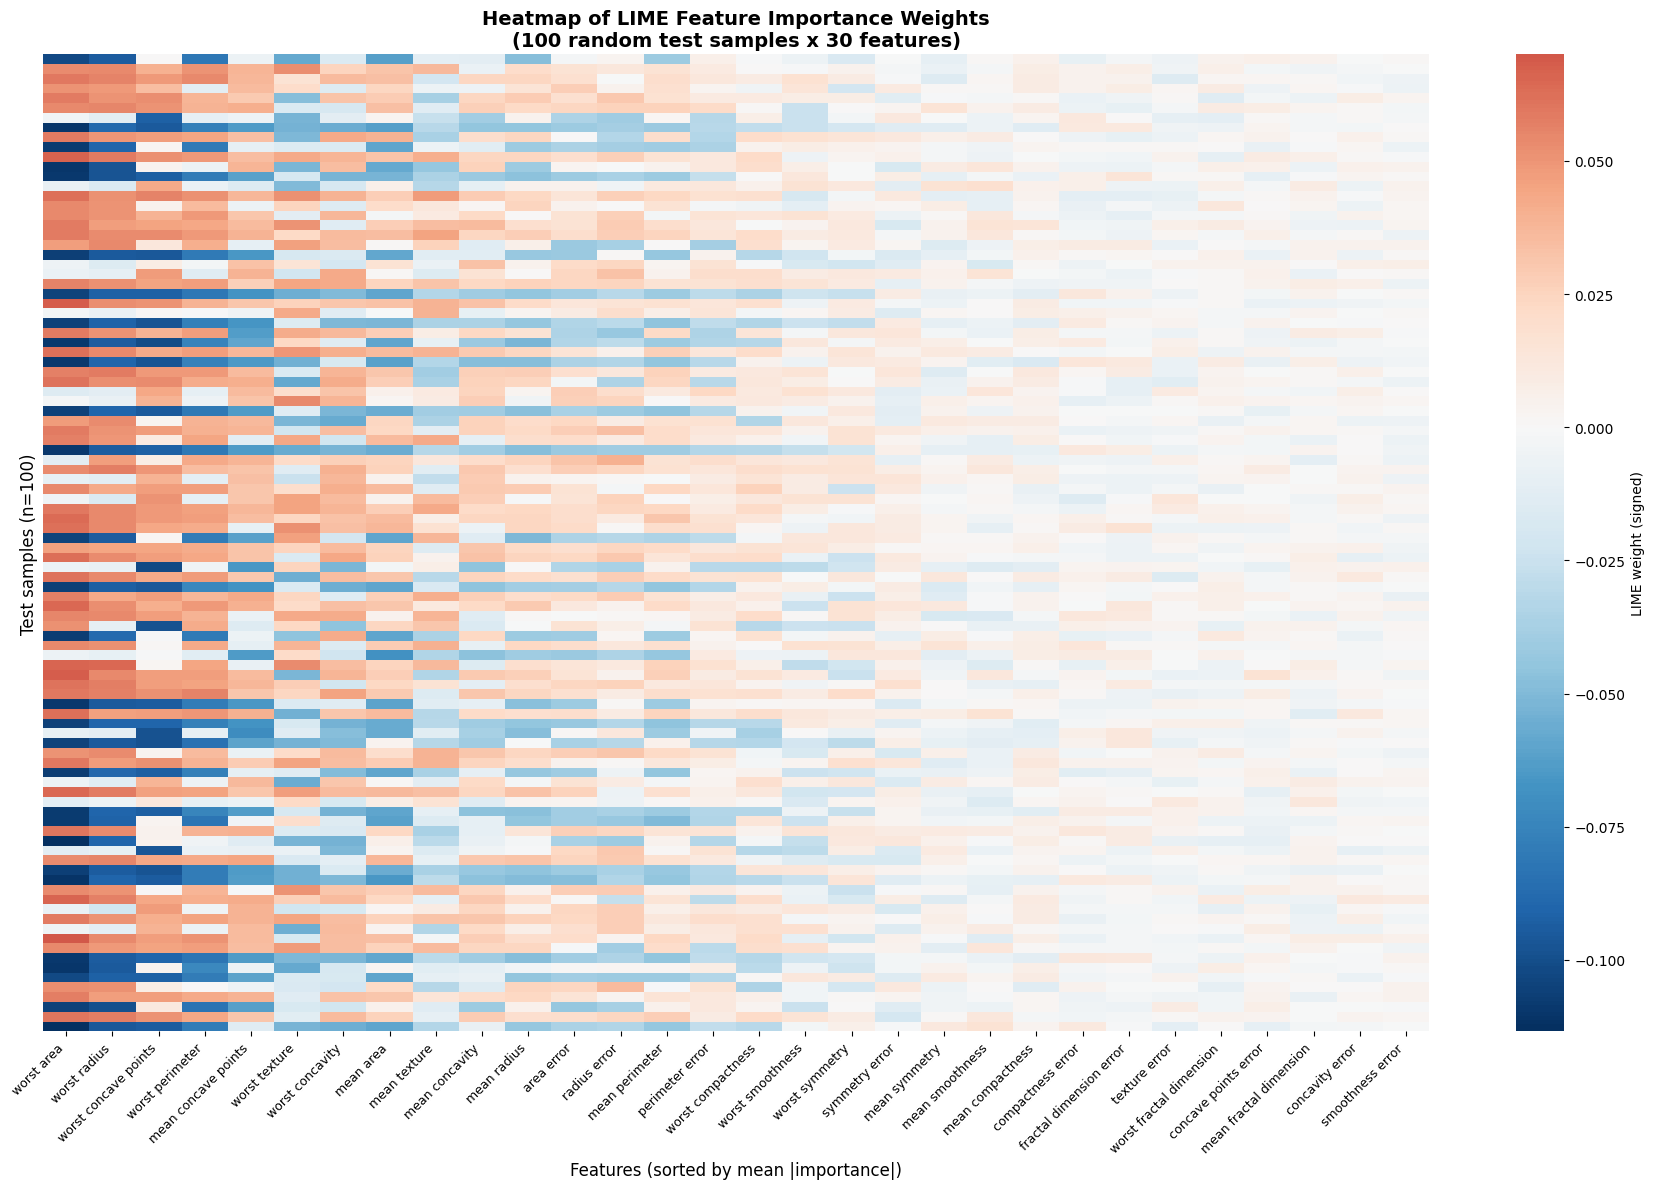

In [40]:
# Your solution here...

# Build heatmap matrix: rows = 100 samples, cols = features, values = LIME weight
heatmap_data = np.zeros((100, len(feature_names)))

for row, i in enumerate(sample_indices):
    exp = lime_tabular.explain_instance(
        X_test_s[i], rf_clf.predict_proba, num_features=len(feature_names)
    )
    pred_label = exp.available_labels()[0]
    for feat_idx, weight in exp.as_map()[pred_label]:
        heatmap_data[row, feat_idx] = weight

heatmap_df = pd.DataFrame(heatmap_data, columns=feature_names)

# Sort columns by mean absolute importance
col_order = heatmap_df.abs().mean().sort_values(ascending=False).index.tolist()
heatmap_df = heatmap_df[col_order]

# Plot heatmap
plt.figure(figsize=(18, 12))
sns.heatmap(
    heatmap_df,
    cmap='RdBu_r',
    center=0,
    xticklabels=True,
    yticklabels=False,
    cbar_kws={'label': 'LIME weight (signed)'}
)
plt.xlabel('Features (sorted by mean |importance|)', fontsize=12)
plt.ylabel('Test samples (n=100)', fontsize=12)
plt.title('Heatmap of LIME Feature Importance Weights\n(100 random test samples x 30 features)',
          fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.show()

**Answer**: It depends. Some features on the left (eg. worst area & radius, worst permiter and mean concave points) show consistent strong weights (and therefore high importance). But there are also lots of features with low importance on the right, so I'd say it isn't consistent.

## SHAP

- **Task (1 point):** Apply SHAP explainer on the trained model. Plot a force plot for the same 4 test samples you had selected for LIME.
- **Task (1 point):** Visualize how each feature contributes to the predicted probability of the selected 4 test samples using the waterfall plot. Compare the results to those from LIME for the same samples. What do you observe?
- **Task (0.5 points):** Plot a summary plot (global overview) of how each feature affects the model's prediction for the complete test set.
- **Task (1 point):** Create a SHAP explainer for the same 100 random test samples you used in the LIME task. Plot a global overview of how each feature affects the model prediction. How does this compare to the global explanations from SP-LIME?
- **Task (0.5 points):** Make a data frame that contains the top 5 most influential features for all test samples.
- **Task (1 point):** Plot a dependence plot for two of the most important features: `worst concave points` and `worst area`.

**Task (1 point):** Apply SHAP explainer on the trained model. Plot a force plot for the same 4 test samples you had selected for LIME.

In [48]:
# Your solution here...

# Build a SHAP explainer function
shap_explainer = shap.Explainer(rf_clf, X_train_s, feature_names=feature_names)

# Plot the explainer
shap.initjs()
shap_values = shap_explainer(X_test_s)

# Force plots for the same 4 samples from LIME
for example_idx, label in [(malignant_idx[0], 'MALIGNANT Sample 1'),
                            (malignant_idx[1], 'MALIGNANT Sample 2'),
                            (benign_idx[0], 'BENIGN Sample 1'),
                            (benign_idx[1], 'BENIGN Sample 2')]:
    print(f"\n{label}:")
    display(shap.plots.force(shap_values[example_idx, :, 1]))


MALIGNANT Sample 1:



MALIGNANT Sample 2:



BENIGN Sample 1:



BENIGN Sample 2:


**Task (1 point):** Visualize how each feature contributes to the predicted probability of the selected 4 test samples using the waterfall plot. Compare the results to those from LIME for the same samples. What do you observe?


MALIGNANT Sample 1:


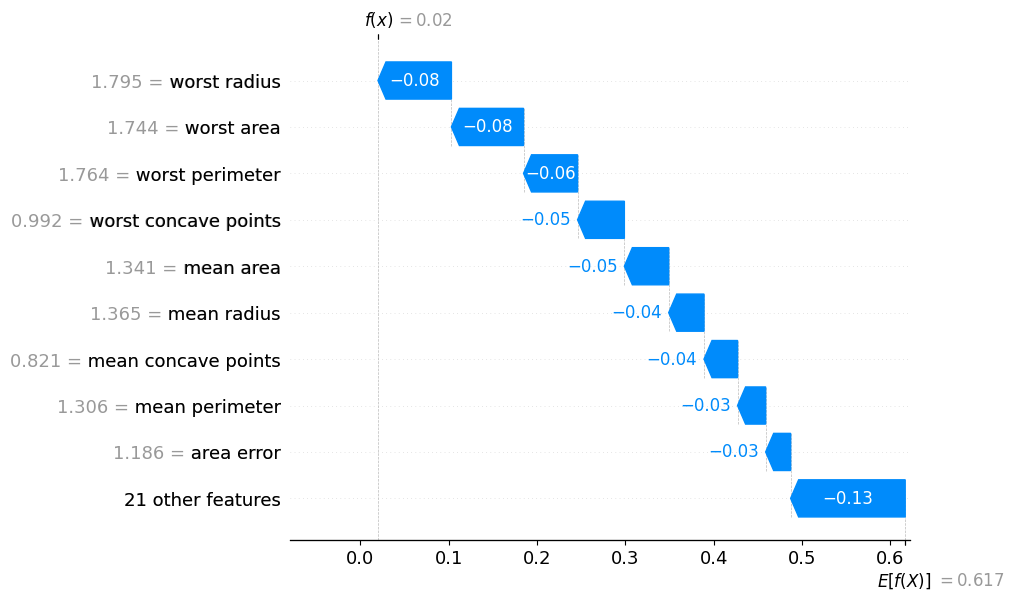

None


MALIGNANT Sample 2:


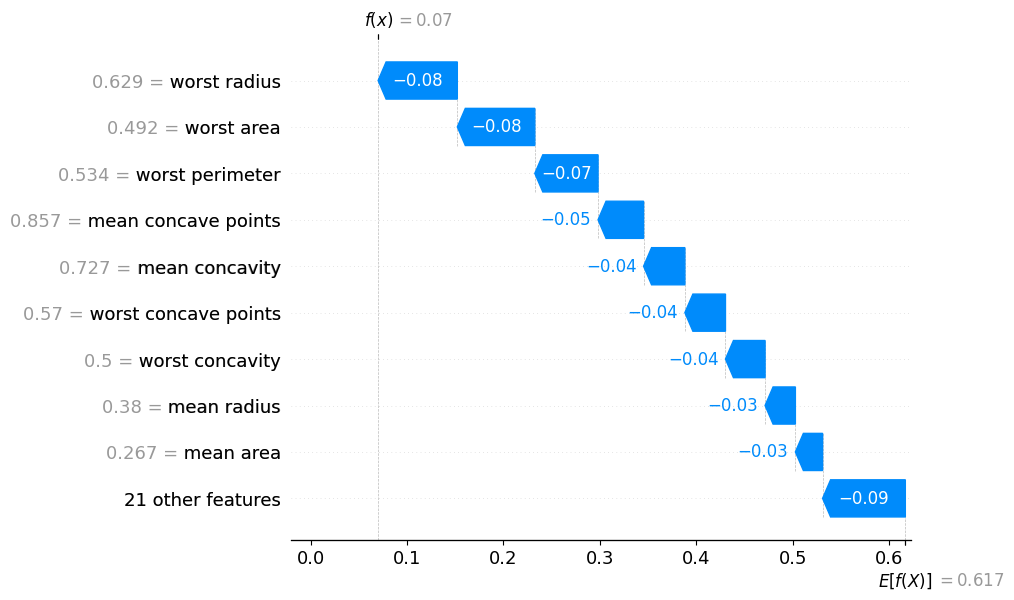

None


BENIGN Sample 1:


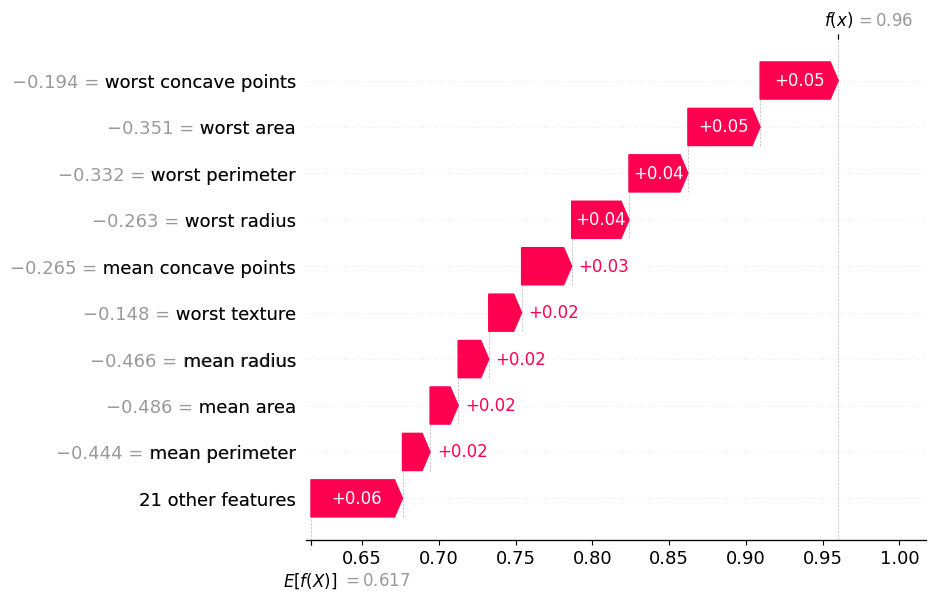

None


BENIGN Sample 2:


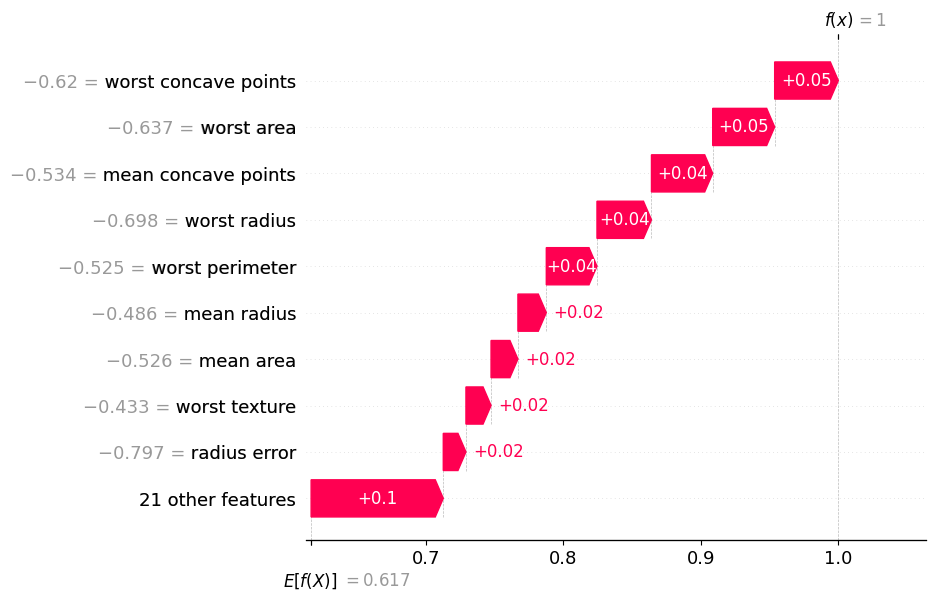

None

In [49]:
# Your solution here...

for example_idx, label in [(malignant_idx[0], 'MALIGNANT Sample 1'),
                            (malignant_idx[1], 'MALIGNANT Sample 2'),
                            (benign_idx[0], 'BENIGN Sample 1'),
                            (benign_idx[1], 'BENIGN Sample 2')]:
    print(f"\n{label}:")
    display(shap.plots.waterfall(shap_values[example_idx, :, 1]))

**Answer**: Overall, the results are quite similar. However, there are some differences (for example Benign Sample 1 has "worst texture" as fourth in LIME, but "worst concave points" in SHAP).
Also with the Malignant Sample, "worst texture" for instance doesn't appear in Sample 1 at all in LIME while it does with SHAP.


**Task (0.5 points):** Plot a summary plot of how each feature affects the model's prediction for the complete test set.

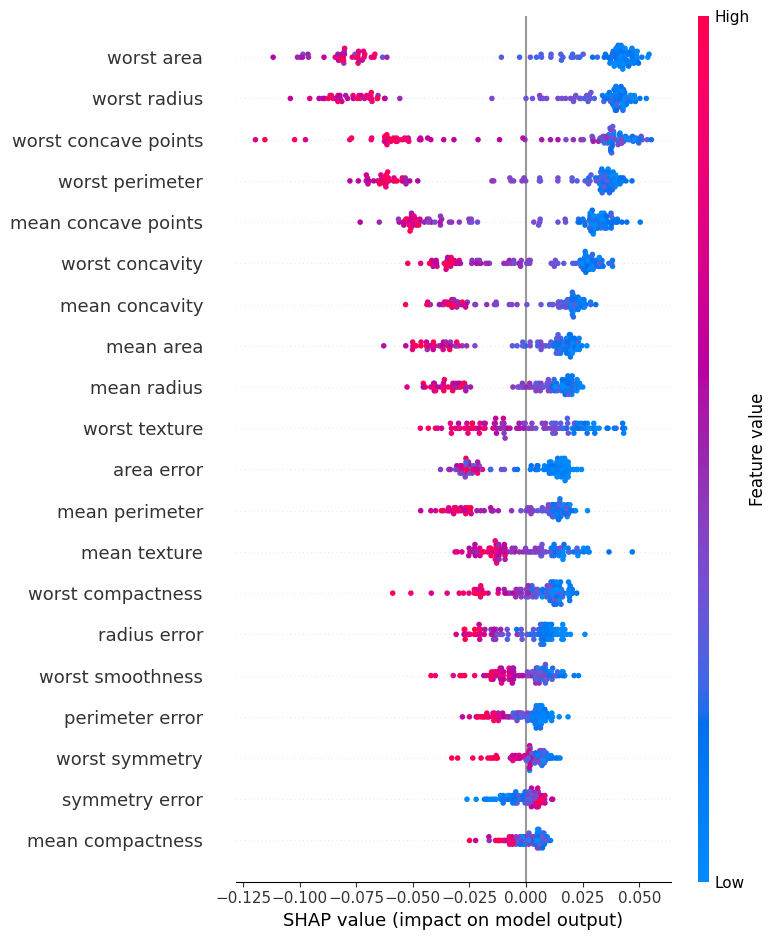

In [51]:
# Your solution here...
shap.summary_plot(shap_values[:, :, 1], X_test_s, feature_names=feature_names)

**Task (1 point):** Create a SHAP explainer for the same 100 random test samples you used in the LIME task. Plot a global overview of how each feature affects the model prediction. How does this compare to the global explanations from SP-LIME?

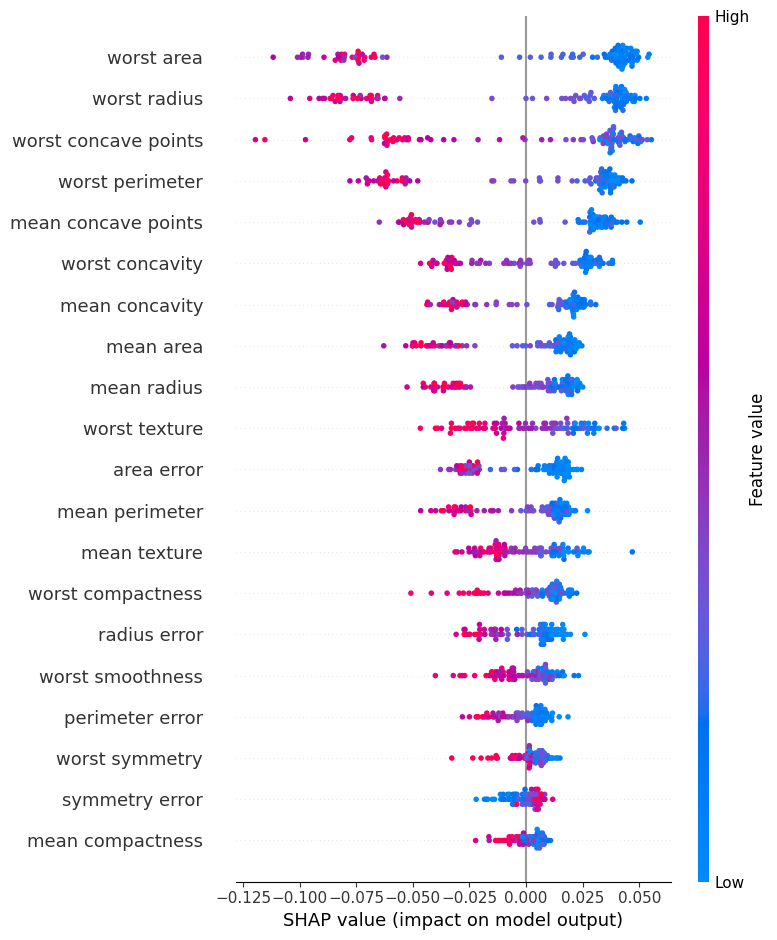

In [52]:
# Your solution here...

shap_values_100 = shap_explainer(X_test_s[sample_indices])
shap.summary_plot(shap_values_100[:, :, 1], X_test_s[sample_indices], feature_names=feature_names)

**Answer**: Here, the results seem to be similar too. Especially the most important four features remain the same, then the order changes slightly.

However, the SHAP view is much more detailed: we can observe the datapoints and not only the means. This gives us insights how much the displayed features contributed to the positive axis as well as the negative one.

**Task (0.5 points):** Make a data frame that contains the top 5 most influential features for all test samples.

In [55]:
# Your solution here...

top5_list = []
for i in range(len(X_test_s)):
    abs_shap = np.abs(shap_values.values[i, :, 1])
    top5_idx = np.argsort(abs_shap)[-5:][::-1]
    top5_list.append({
        'Sample': i,
        'Feature 1': feature_names[top5_idx[0]],
        'Feature 2': feature_names[top5_idx[1]],
        'Feature 3': feature_names[top5_idx[2]],
        'Feature 4': feature_names[top5_idx[3]],
        'Feature 5': feature_names[top5_idx[4]],
    })

top5_df = pd.DataFrame(top5_list)
display(top5_df)

,Sample,Feature 1,Feature 2,Feature 3,Feature 4,Feature 5
0,0,worst concave points,worst area,worst perimeter,worst radius,mean concave points
1,1,worst radius,worst area,worst perimeter,worst concave points,mean area
2,2,worst radius,worst area,worst perimeter,mean concave points,mean concavity
3,3,worst concave points,worst area,mean concave points,worst radius,worst perimeter
4,4,worst concave points,worst radius,worst area,mean concave points,worst perimeter
...,...,...,...,...,...,...
109,109,worst concave points,mean fractal dimension,mean concave points,mean texture,fractal dimension error
110,110,worst area,worst radius,worst perimeter,mean radius,worst concave points
111,111,worst radius,worst area,worst concave points,worst perimeter,worst concavity
112,112,worst concave points,worst texture,mean concave points,worst smoothness,mean concavity


**Task (1 point):** Plot a dependence plot for two of the most important features: `worst concave points` and `worst area`.

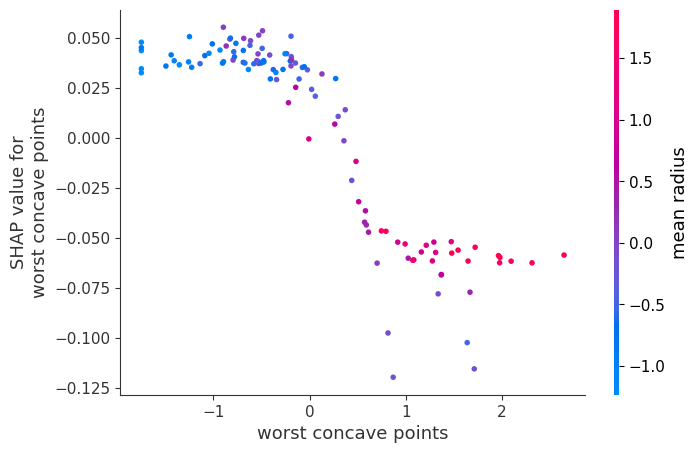

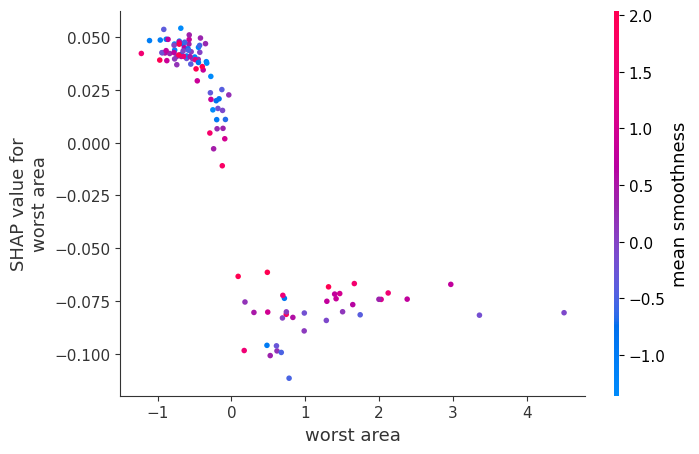

In [60]:
# Your solution here...
shap.dependence_plot('worst concave points', shap_values.values[:, :, 1], X_test_s,
                     feature_names=feature_names)

shap.dependence_plot('worst area', shap_values.values[:, :, 1], X_test_s,
                     feature_names=feature_names)